In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

from cndlles.preprocess import preprocess
from cndlles.torch_util import *
from cndlles.plot_helpers import plot_losses
from cndlles.plot_helpers import plot_scatter

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import pickle
import torch
import torch.utils.data as Data

In [4]:
size=3  # Horizontal size of input planes, always 3 in vertical
sizeStr = str(size)
# Nhid = [512,256,128,64]  # Multiplicity of hidden layers
# Nhid = [128,64,32,16]  # Multiplicity of hidden layers
Nhid = [64,32,16,8]  # Multiplicity of hidden layers
Nruns = 2

In [5]:
saveFile='C4_midGridReInterp_'
plotLosses = True
plotQuickPlots = True
## Training datasets
files=["coarse4x1026_Re900.nc","coarse4x3078_Re2700.nc"]

# Scaling factors based on exogenous forcing
# Note, lower Re in file names uses a viscous length scale from the
# DNS while LES scaling factors use the BL depth as length scale
fileRes=[20000.,60000.] # Re = 20k, 40k, 60k for Re900, Re1800, Re2700
fileUgs=[0.025,0.075] # 0.025, 0.05, 0.075
fileB0s=[-0.0005, -0.0349]
filemaskpercents=[1./10,1]
# filemaskpercents=[1e-3,1e-2]

In [6]:
# Test (reported statistics) and Validation (early stopping) data
testFiles=["coarse4x2052_Re1800.nc"]
testfileUgs=[0.05]
testfileRes=[40000.]
testfileB0s=[-0.0044]
testfilemaskpercents=[0.4] 
# testfilemaskpercents=[1e-3]

In [7]:
# Half testFiles' data, after per file masking above, used for early stopping
valMaskPercent = 0.5 

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [9]:
save=1
savePath='trainedModels/'
for n in range(len(files)):
    isep = files[n].index('_')
    saveFile=saveFile+files[n][6:isep]+files[n][isep+1:-3]+'_'
print(saveFile)
plotPath='quickPlots/'

C4_midGridReInterp_4x1026Re900_4x3078Re2700_


In [10]:
y_text = ["tau_11", "tau_12", "tau_13","tau_22", "tau_23", "tau_33"]
r=np.empty((Nruns,len(y_text))) 
r2=np.empty((Nruns,len(y_text)))
auxDataDict=dict()

Train Files:
coarse4x1026_Re900.nc
coarse4x3078_Re2700.nc
output shape is (141312, 6)
input shape was (141312, 4, 3, 3, 3)
input shape to do 3rd dimension as channel in R2Conv is (141312, 12, 3, 3)
Test Files:
coarse4x2052_Re1800.nc
output shape is (282591, 6)
input shape was (282591, 4, 3, 3, 3)
input shape to do 3rd dimension as channel in R2Conv is (282591, 12, 3, 3)
Lossweights:
[0.01334746 0.05355067 0.23587488 0.03023743 0.34491493 0.26809363]
Epoch: 0
LR:  [0.01]
train loss: 0.3521554070104704
validation loss: 0.20438566996476004
test loss: 0.2038955809634923
Epoch: 1
LR:  [0.001]
train loss: 0.3439388042159472
validation loss: 0.20319253222445013
test loss: 0.20264645882337792
Epoch: 2
LR:  [0.0001]
train loss: 0.34306752146477437
validation loss: 0.20532087266198915
test loss: 0.20474846396683197
Epoch: 3
LR:  [0.0001]
train loss: 0.3425046735006825
validation loss: 0.20342998827712058
test loss: 0.2028512340485722
Epoch: 4
LR:  [0.0001]
train loss: 0.3419430560757265
validati

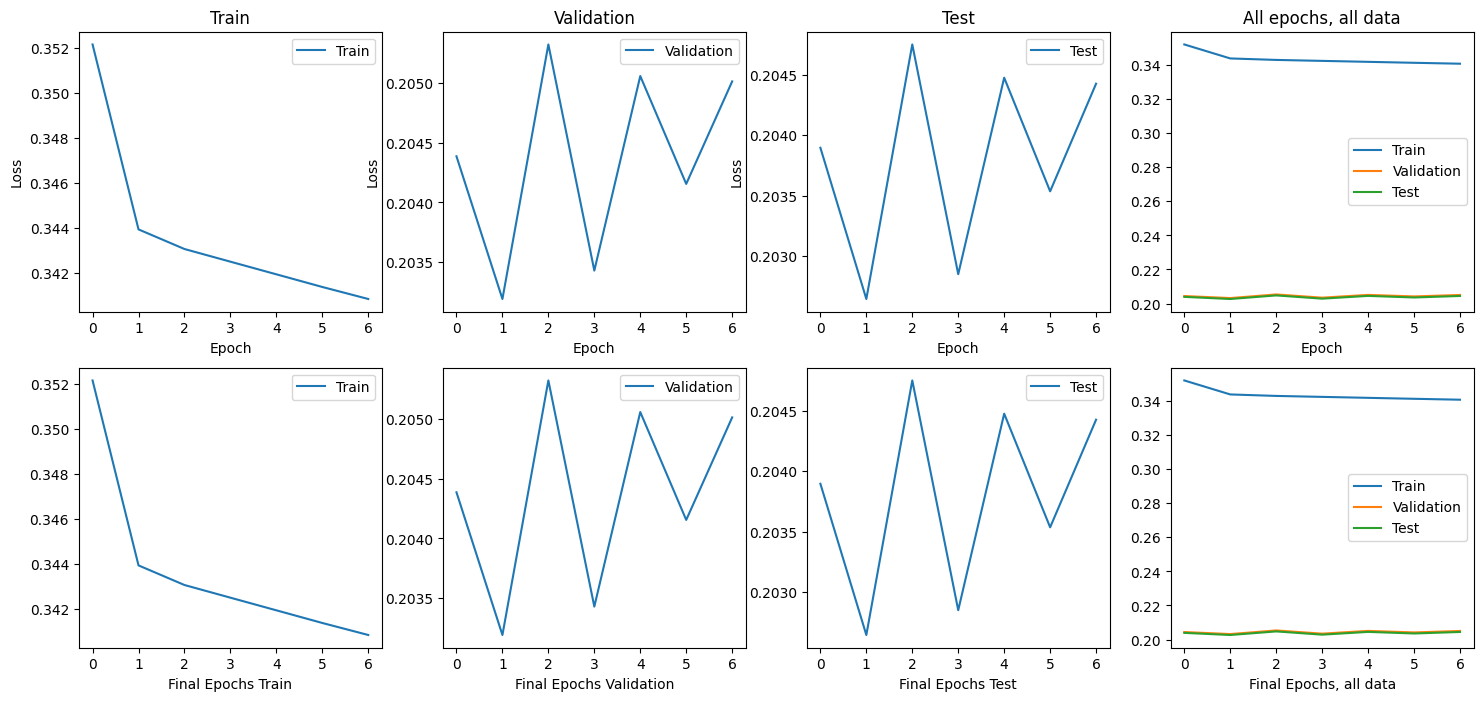

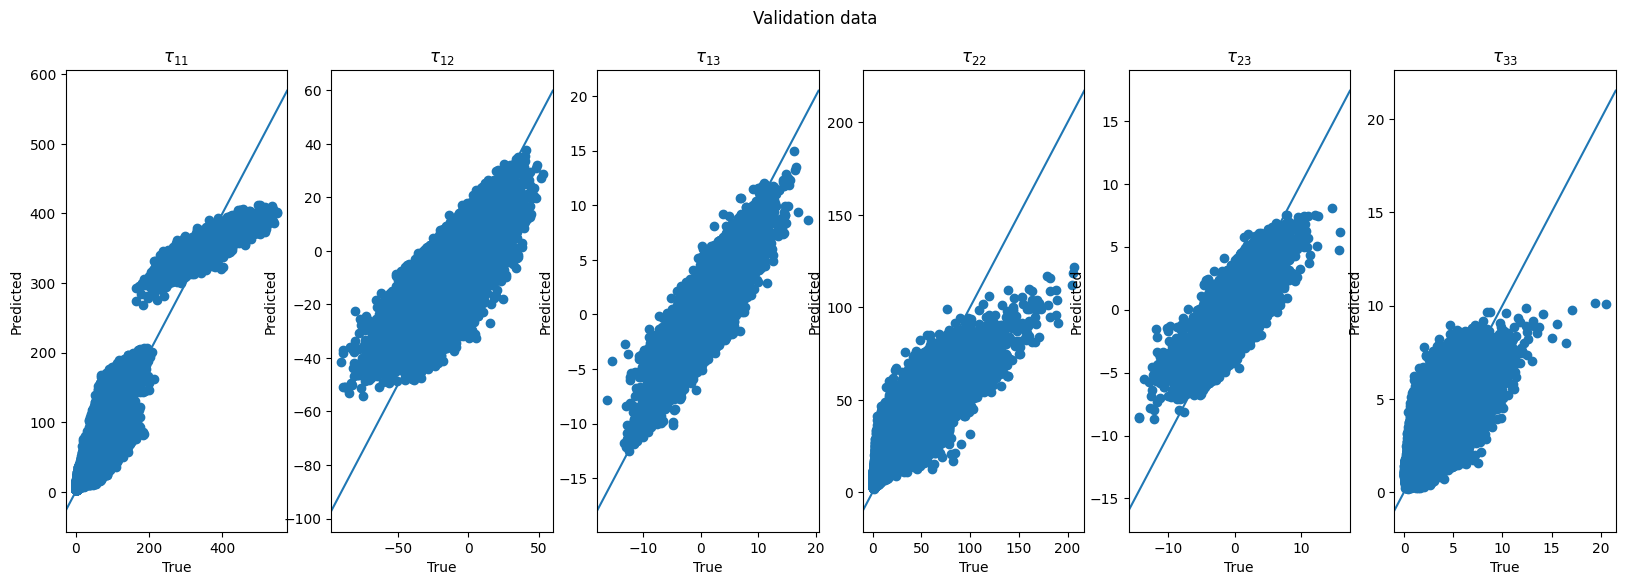

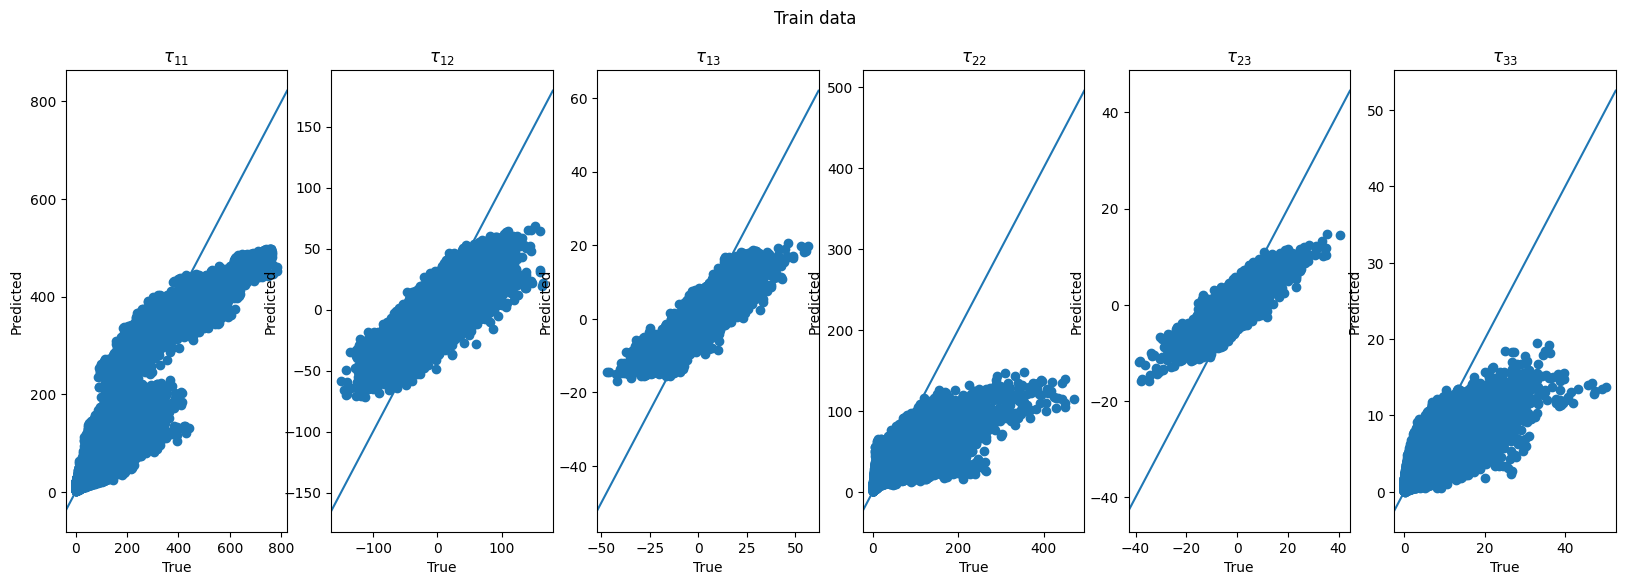

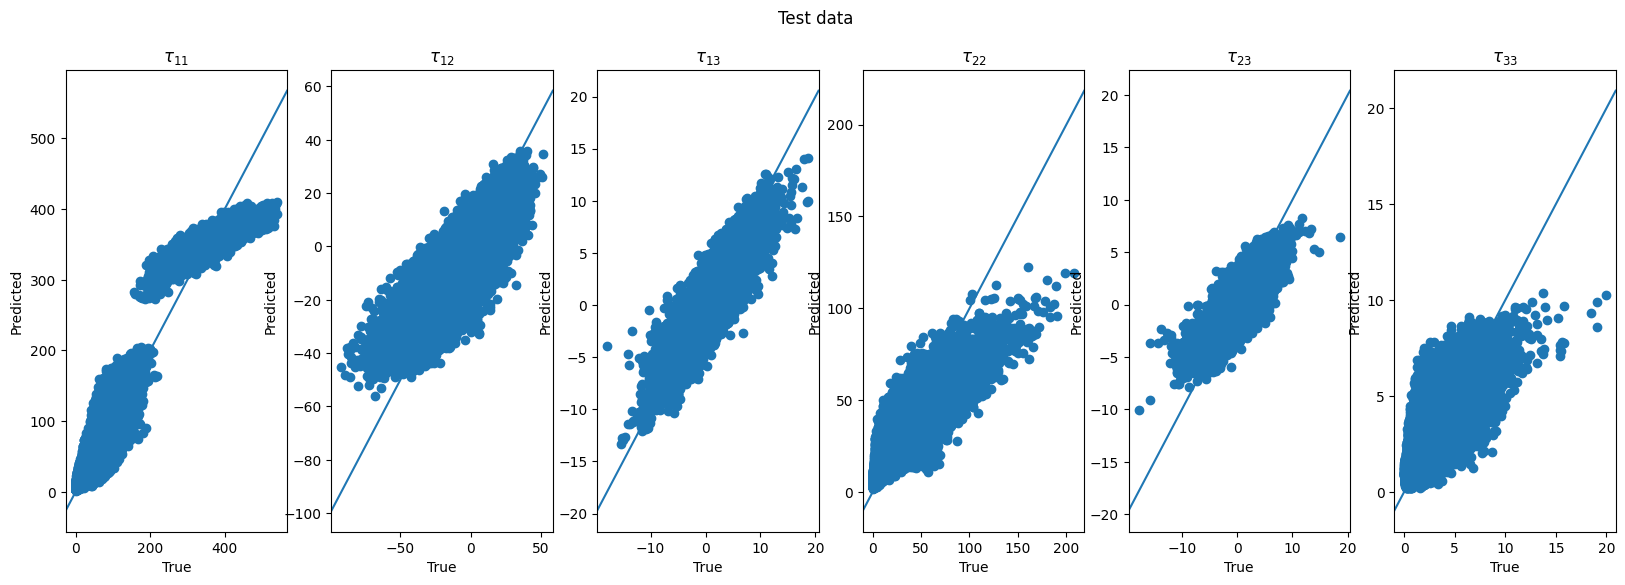

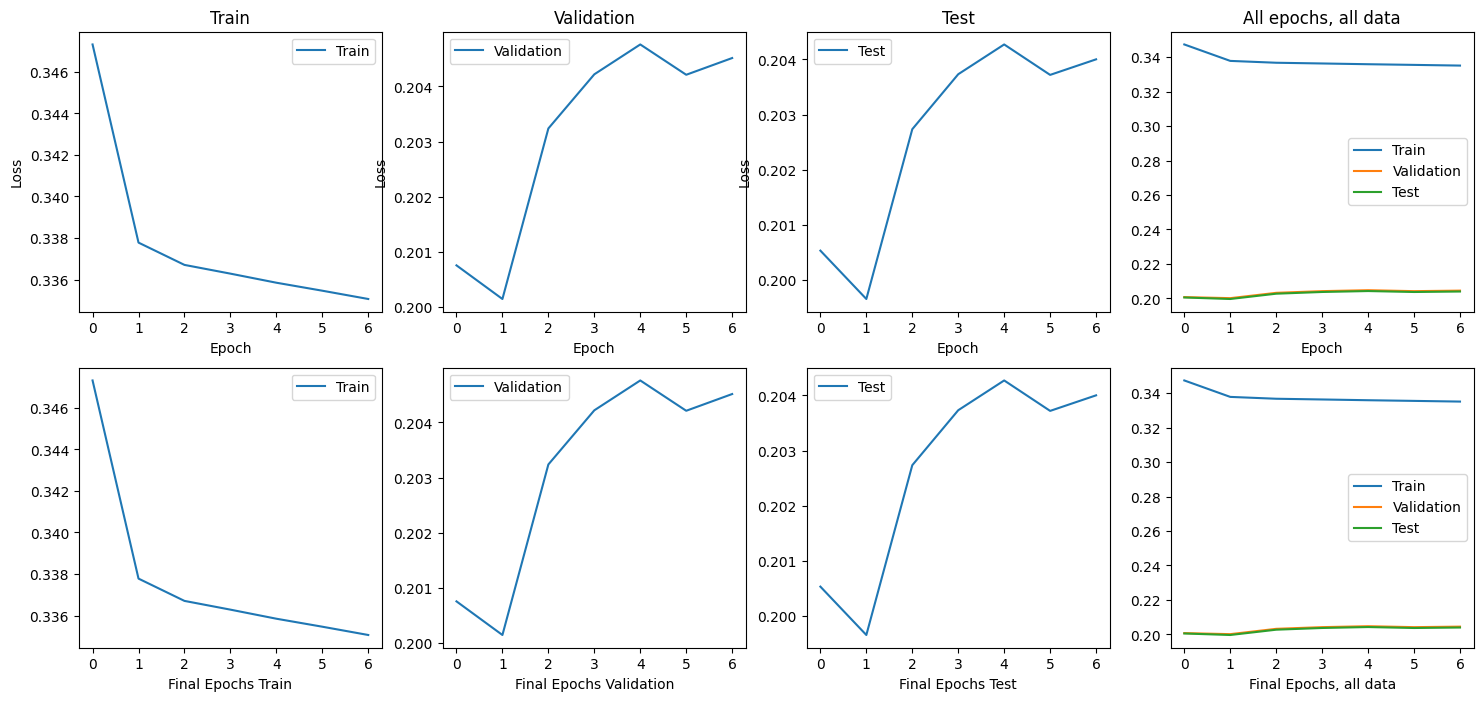

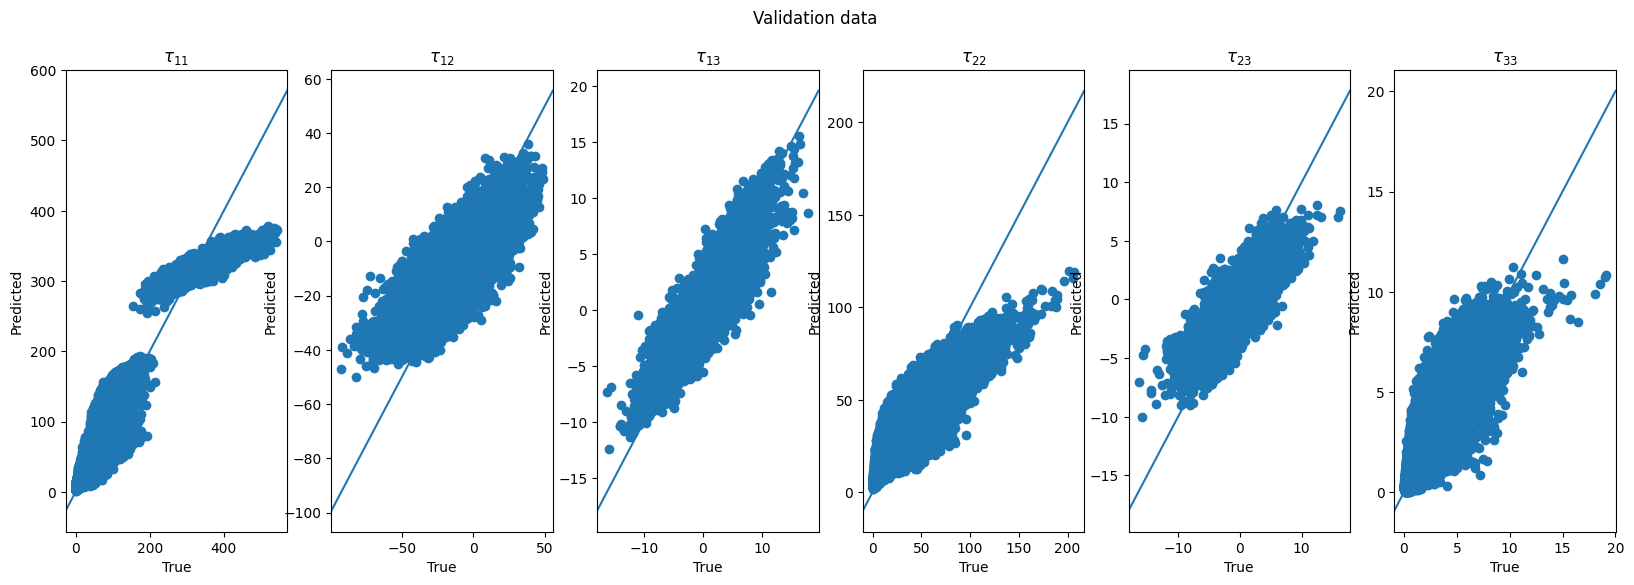

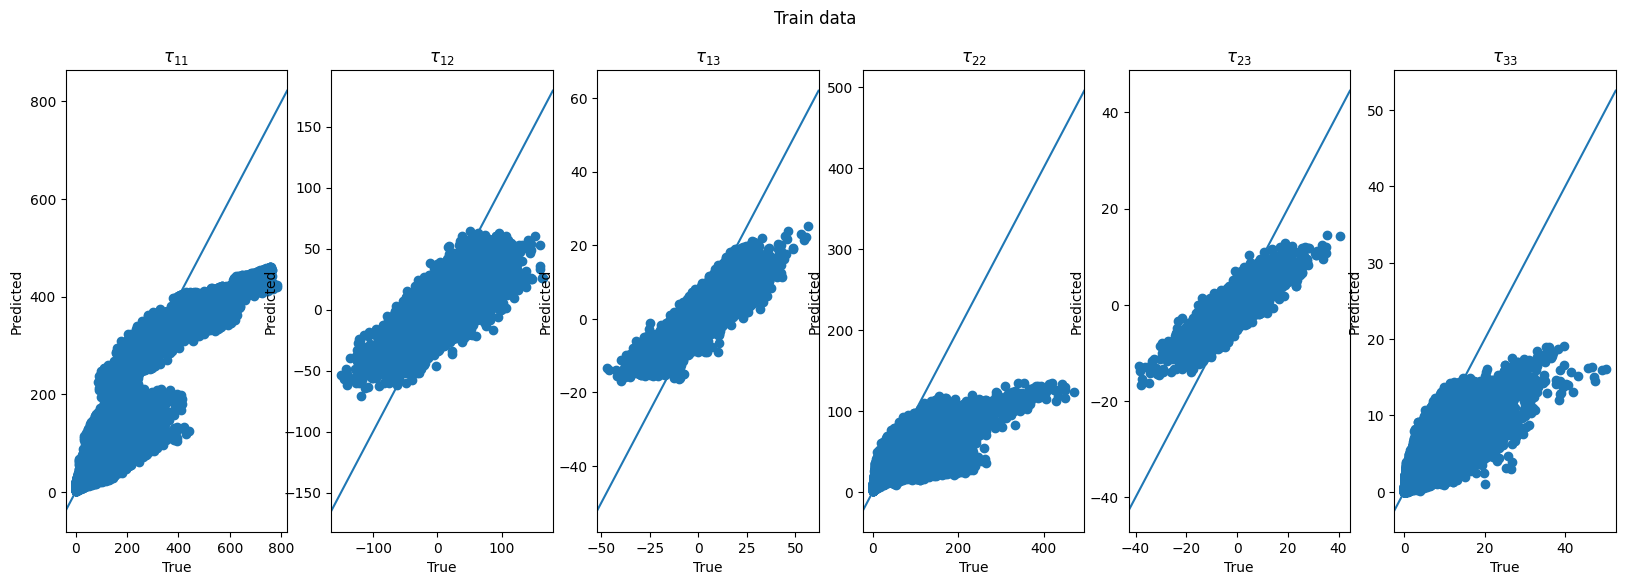

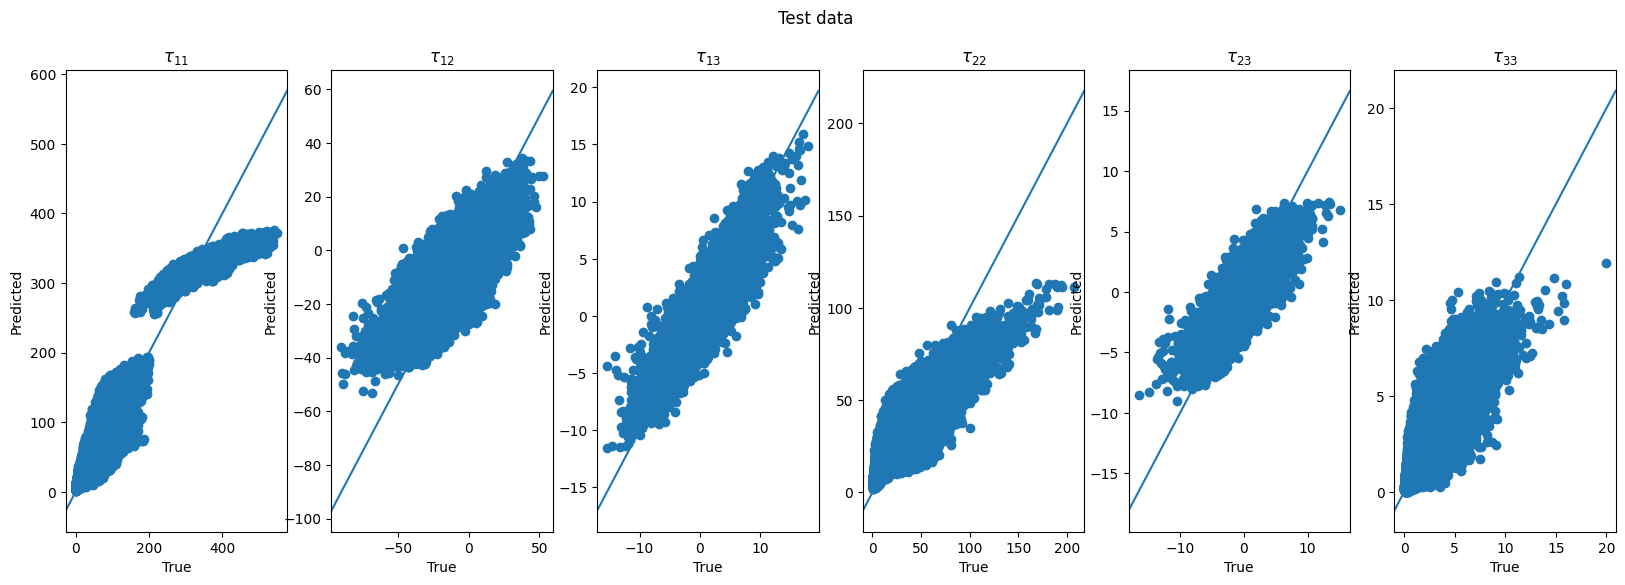

In [11]:
# BATCH_SIZE = 1024 # Number of sample in each batch
# n_epochs = 500 # Max number of epochs
# patience = 20
BATCH_SIZE = 1024 # Number of sample in each batch
n_epochs = 20 # Max number of epochs
patience = 5

for irun in range(Nruns):

    print("Train Files:")
    x_train, y_train, trainMask = preprocess(files, filemaskpercents, fileUgs, fileRes, fileB0s, size, irun)
    auxDataDict.update(trainMask)

    torch_dataset = Data.TensorDataset(torch.from_numpy(x_train).float(),torch.from_numpy(y_train).float())
    loader = Data.DataLoader(dataset=torch_dataset, batch_size=BATCH_SIZE, shuffle=True)

    print("Test Files:")
    xtest, ytest, testMask = preprocess(testFiles, testfilemaskpercents, testfileUgs, testfileRes, testfileB0s, size, irun)
    auxDataDict.update(testMask) 

    # Note, mask_[irun]_* uses original spatial indices, but valMask is by sample
    mask =  np.random.rand(xtest.shape[0]) > valMaskPercent
    auxDataDict["valMask_"+str(irun)]=mask
    x_test=xtest[mask]
    x_val=xtest[~mask]
    del xtest
    y_test=ytest[mask]
    y_val=ytest[~mask]
    del ytest

    torch_dataset_test = Data.TensorDataset(torch.from_numpy(x_test).float(),torch.from_numpy(y_test).float())
    loader_test = Data.DataLoader(dataset=torch_dataset_test,batch_size=BATCH_SIZE,shuffle=True)

    torch_dataset_val = Data.TensorDataset(torch.from_numpy(x_val).float(),torch.from_numpy(y_val).float())
    loader_val = Data.DataLoader(dataset=torch_dataset_val,batch_size=BATCH_SIZE,shuffle=True)

    # Lossweights to balance components
    numerator=1
    LossWeights = np.array([numerator/np.std(y_train[:,i]) for i in range(y_train.shape[1])])
    print('Lossweights:')
    print(LossWeights)
    weights=torch.from_numpy(LossWeights).to(device)
    

    model=CNDNN(Nhid,N=4,size=size,device=device).float().to(device)
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer,range(1,3), gamma=0.10)
    early_stopper = EarlyStopper(patience=patience, min_delta=0)
    criterion = torch.nn.L1Loss() # MSE loss function

    validation_loss = list()
    train_loss = list()
    test_loss = list()
    min_loss = np.inf

    for epoch in range(n_epochs):
        print('Epoch: '+str(epoch))
        print('LR: ',scheduler.get_last_lr())
        
        train_model(model, criterion, loader, optimizer, scheduler, weights, device)
        
        train_loss.append(test_model(model, criterion, loader, weights, device, 'train'))
        validation_loss.append(test_model(model, criterion, loader_val, weights, device))
        test_loss.append(test_model(model, criterion, loader_test, weights, device, 'test'))
        
        if validation_loss[-1] < min_loss:
            torch.save(model.state_dict(),savePath+saveFile+str(irun)+'.pt')
            min_loss = validation_loss[-1]
        if early_stopper.early_stop(validation_loss[-1]):
            print('ES epoch: '+str(epoch-patience))
            break

    # Reloading best model weights
    model.load_state_dict(torch.load(savePath+saveFile+str(irun)+'.pt'))

    auxDataDict["train_loss_"+str(irun)]=train_loss
    auxDataDict["validation_loss_"+str(irun)]=validation_loss
    auxDataDict["test_loss_"+str(irun)]=test_loss

    zoomEndEpochs = np.max((2 * early_stopper.patience, n_epochs))
    if plotLosses:
        plot_losses(
                [train_loss, validation_loss, test_loss],
                ["Train", "Validation", "Test"], 
                cutStartPct = 0., zoomEndEpochs = zoomEndEpochs 
                  )
        plt.savefig(plotPath+saveFile+str(irun)+'_lossCurve.png')
    if plotQuickPlots:
        plot_scatter(model, device,
                                x_val, y_val,
                                # weights = LossWeights,
                                text = "Validation data",
                   )
        plt.savefig(plotPath+saveFile+str(irun)+'_valStats.png')
    
        plot_scatter(model, device,
                                x_train, y_train,
                                # weights = LossWeights,
                                text = "Train data",
                   )
        plt.savefig(plotPath+saveFile+str(irun)+'_trainStats.png')
    
        y_pred = plot_scatter(model, device,
                                x_test, y_test,
                                # weights = LossWeights,
                                text = "Test data",
                                return_predictions = True
                   )
        plt.savefig(plotPath+saveFile+str(irun)+'_TestStats.png')
    
    # else: # Not implemented b/c always want to plot and return predictions then
    #     yp = get_predictions( <Test Data> ) # to save on inference

    r2[irun]=[r2_score(y_test[:,i], y_pred[:,i]) for i in range(y_pred.shape[1])]
    r[irun]=[np.corrcoef(y_test[:,i], y_pred[:,i])[0, 1] for i in range(y_pred.shape[1])]

    torch.cuda.empty_cache()
    del model, optimizer, scheduler


In [12]:
print(r)
print(r2)

[[0.97054556 0.84040436 0.83910152 0.84125871 0.7787811  0.76031753]
 [0.96926008 0.83574326 0.83639505 0.86051744 0.78329439 0.80745514]]
[[0.93279038 0.69991444 0.68565669 0.53816844 0.5747915  0.30340792]
 [0.92722736 0.69727915 0.68756057 0.57550332 0.59193644 0.30521333]]


In [13]:
auxDataDict["r"] = r
auxDataDict["Rsquared"] = r2

In [14]:
for v in range(r2.shape[1]):
        print(y_text[v]+r' avg. R$^2$ is '+str(np.mean(r2[:,v]))+' +/- '+str(np.std(r2[:,v])))
print('Overall avg. R^2 is '+str(np.mean(r2))+' +/- '+str(np.std(np.mean(r2,axis=1))))
pickle.dump(auxDataDict,open(savePath+saveFile[:-1]+'.pkl', "wb" ))

tau_11 avg. R$^2$ is 0.93000886995652 +/- 0.002781506761431962
tau_12 avg. R$^2$ is 0.6985967979016303 +/- 0.001317645399168288
tau_13 avg. R$^2$ is 0.6866086342038336 +/- 0.000951939616388231
tau_22 avg. R$^2$ is 0.5568358783350045 +/- 0.01866743772588464
tau_23 avg. R$^2$ is 0.5833639699259975 +/- 0.008572467099649761
tau_33 avg. R$^2$ is 0.3043106257685329 +/- 0.000902701152072416
Overall avg. R^2 is 0.6266207960152531 +/- 0.004165898905565735
